In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e6/train.csv
/kaggle/input/competitions/playground-series-s6e6/test.csv


In [2]:
X_full = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv', index_col='id')
X_test_full = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv', index_col='id')
print(X_full.shape)
print(X_test_full.shape)
print(X_full.head())

(577347, 11)
(247435, 10)
         alpha      delta          u          g          r          i  \
id                                                                      
0   147.734256  16.959273  25.472123  21.895559  20.357926  19.257113   
1   127.988677  32.346716  20.778509  19.087062  17.587208  17.226067   
2   179.792648  35.344843  21.035203  21.079128  21.171840  20.582629   
3   225.818295  48.569421  23.305056  21.050736  19.017754  18.365658   
4   141.836135  19.342852  21.703158  19.471680  18.234449  17.899447   

            z  redshift spectral_type galaxy_population   class  
id                                                               
0   18.621057  0.408982             M      Red_Sequence  GALAXY  
1   16.786433  0.157976             M      Red_Sequence  GALAXY  
2   20.557366  2.823770           O/B        Blue_Cloud     QSO  
3   17.914952  0.536099             M      Red_Sequence  GALAXY  
4   17.616185  0.555761             M      Red_Sequence  GALAXY  


Drop missing values from the class category(if any).

In [3]:

X_full.dropna(axis=0, subset=['class'], inplace=True)
print(X_full.shape)
# same number of row == no missing values
print(X_full['class'].value_counts())
y = X_full['class']
X = X_full.drop(['class'], axis=1)
X['redshift_log'] = np.log1p(np.log1p(X['redshift']))
X_test_full['redshift_log'] = np.log1p(np.log1p(X_test_full['redshift']))
for col in X_full:
    print(X_full[col].describe())

(577347, 11)
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64
count    577347.000000
mean        181.616673
std          96.242941
min           0.011684
25%         132.161499
50%         188.681465
75%         231.829693
max         359.999810
Name: alpha, dtype: float64
count    577347.000000
mean         21.834654
std          18.933570
min         -17.966988
25%           2.474097
50%          21.484412
75%          36.988310
max          79.158322
Name: delta, dtype: float64
count    577347.000000
mean         22.441926
std           2.018135
min          -0.139225
25%          20.977090
50%          22.570222
75%          23.869103
max          28.253263
Name: u, dtype: float64
count    577347.000000
mean         21.007273
std           1.795426
min          13.535483
25%          19.865005
50%          21.467820
75%          22.292715
max          27.620208
Name: g, dtype: float64
count    577347.000000
mean         19.962811
std           1.64

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 800x500 with 0 Axes>

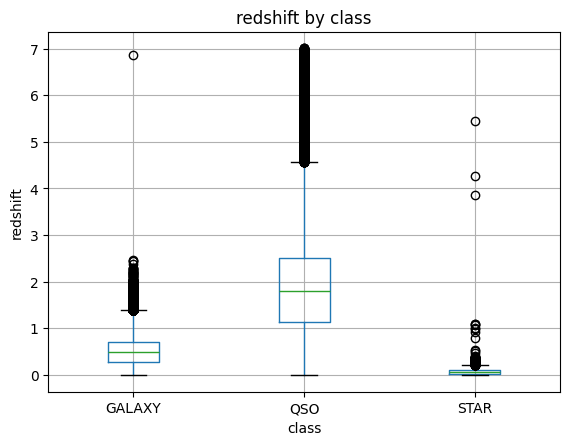

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))
X_full.boxplot(column='redshift', by='class')
plt.title('redshift by class')
plt.suptitle('')
plt.xlabel('class')
plt.ylabel('redshift')
plt.show



check individual columns to find NaN

In [5]:
missing = [cname for cname in X if X[cname].isna().sum()]
print(missing == [])
# other columns got no missing data

True


In [6]:
categorical_cols = [cname for cname in X if X[cname].dtype == 'object']
print('Categorical columns:', categorical_cols)
numerical_cols = [cname for cname in X if X[cname].dtype in ['float64', 'int64']]
print('Numerical Columns:', numerical_cols)

Categorical columns: ['spectral_type', 'galaxy_population']
Numerical Columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'redshift_log']


distinguish columns

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=42, stratify=y)
train_X = train_X.copy()
val_X = val_X.copy()
for df in [train_X, val_X, X_test_full]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_z'] = df['u'] - df['z']
categorical_cols = [cname for cname in train_X if train_X[cname].dtype == 'object']
print('Categorical columns:', categorical_cols)
numerical_cols = [cname for cname in train_X if train_X[cname].dtype in ['float64', 'int64']]
print('Numerical Columns:', numerical_cols)
for col in numerical_cols:
    print(f"{col}: {train_X[col].skew():.3f}")
le = LabelEncoder()
encoded_train_y = le.fit_transform(train_y)
encoded_valid_y = le.transform(val_y)
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_cols),  # no imputation needed
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

final_X_train = preprocessor.fit_transform(train_X)
final_X_valid = preprocessor.transform(val_X)

print(set(train_X.columns) - set(X_test_full.columns))  
print(set(X_test_full.columns) - set(train_X.columns)) 

Categorical columns: ['spectral_type', 'galaxy_population']
Numerical Columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'redshift_log', 'u_g', 'g_r', 'r_i', 'i_z', 'u_z']
alpha: -0.055
delta: 0.174
u: -0.116
g: -0.630
r: -0.663
i: -0.480
z: -0.313
redshift: 2.301
redshift_log: 0.527
u_g: 0.580
g_r: 0.026
r_i: 0.073
i_z: -0.536
u_z: 0.123
set()
set()


skewness > 1 for redshift suggests data is skewed, so lg redshift before splitting.

In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import balanced_accuracy_score
#train XGBoost first
print("Training XGB:")
xgb_model = XGBClassifier(n_estimators=1500, learning_rate=0.05, early_stopping_rounds=100, random_state=42)
xgb_model.fit(final_X_train, encoded_train_y, eval_set=[(final_X_valid, encoded_valid_y)], verbose=100)

xgb_preds = xgb_model.predict(final_X_valid)
#find score for each model
print(f"XGB:  {balanced_accuracy_score(encoded_valid_y, xgb_preds):.4f}")

#cm = confusion_matrix(encoded_valid_y, preds)
#print(score)
#plt.figure(figsize=(6,5))
#sns.heatmap(cm, annot=True, fmt='d',\
#           xticklabels=le.classes_,\
#           yticklabels=le.classes_,\
#           cmap='Blues')

#plt.title('Confusion_matrix')
#plt.ylabel('Actual')
#plt.xlabel('Predicted')
#plt.show()

Training XGB:
[0]	validation_0-mlogloss:0.81982
[100]	validation_0-mlogloss:0.11954
[200]	validation_0-mlogloss:0.10311
[300]	validation_0-mlogloss:0.09825
[400]	validation_0-mlogloss:0.09543
[500]	validation_0-mlogloss:0.09384
[600]	validation_0-mlogloss:0.09274
[700]	validation_0-mlogloss:0.09191
[800]	validation_0-mlogloss:0.09158
[900]	validation_0-mlogloss:0.09130
[1000]	validation_0-mlogloss:0.09112
[1100]	validation_0-mlogloss:0.09101
[1200]	validation_0-mlogloss:0.09100
[1300]	validation_0-mlogloss:0.09092
[1400]	validation_0-mlogloss:0.09094
[1402]	validation_0-mlogloss:0.09094
XGB:  0.9545


In [9]:
#train lightgbm second
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import balanced_accuracy_score
print("Training GBM:")
lgbm_model = LGBMClassifier(n_estimators=2200, 
                            learning_rate=0.01,
                            num_leaves=225,
                            min_child_samples=50,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            class_weight='balanced',
                            random_state=42)
lgbm_model.fit(final_X_train, encoded_train_y, eval_set=[(final_X_valid, encoded_valid_y)], callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)])
lgbm_preds = lgbm_model.predict(final_X_valid)
print(f"LGBM: {balanced_accuracy_score(encoded_valid_y, lgbm_preds):.4f}")

Training GBM:
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3582
[LightGBM] [Info] Number of data points in the train set: 433010, number of used features: 20
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 0.341797
[200]	valid_0's multi_logloss: 0.183396
[300]	valid_0's multi_logloss: 0.13947
[400]	valid_0's multi_logloss: 0.122797
[500]	valid_0's multi_logloss: 0.113407
[600]	valid_0's multi_logloss: 0.108698
[700]	valid_0's multi_logloss: 0.105927
[800]	valid_0's multi_logloss: 0.1041
[900]	valid_0's multi_logloss: 0.102838
[1000]	valid_0's multi_logloss: 0.101831
[1100]	valid_0's multi_logloss: 0.101013
[1200]	valid_0's multi_logloss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM: 0.9640


In [10]:
#train catboost last
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score
cb_model = CatBoostClassifier(iterations=1500, learning_rate=0.05, depth=8, early_stopping_rounds=50, auto_class_weights='Balanced', min_data_in_leaf=50, random_state=42, verbose=100)
cb_model.fit(final_X_train, encoded_train_y, eval_set=[(final_X_valid, encoded_valid_y)])

cb_preds = cb_model.predict(final_X_valid)
print(f"CatBoost: {balanced_accuracy_score(encoded_valid_y, cb_preds):.4f}")

0:	learn: 1.0195011	test: 1.0194886	best: 1.0194886 (0)	total: 357ms	remaining: 8m 54s
100:	learn: 0.1441777	test: 0.1448422	best: 0.1448422 (100)	total: 29.9s	remaining: 6m 54s
200:	learn: 0.1226754	test: 0.1246012	best: 0.1246012 (200)	total: 1m	remaining: 6m 28s
300:	learn: 0.1140690	test: 0.1173581	best: 0.1173581 (300)	total: 1m 30s	remaining: 5m 58s
400:	learn: 0.1091645	test: 0.1139643	best: 0.1139643 (400)	total: 1m 59s	remaining: 5m 27s
500:	learn: 0.1054785	test: 0.1117040	best: 0.1117040 (500)	total: 2m 28s	remaining: 4m 56s
600:	learn: 0.1024784	test: 0.1101146	best: 0.1101146 (600)	total: 2m 57s	remaining: 4m 26s
700:	learn: 0.0998903	test: 0.1089131	best: 0.1089131 (700)	total: 3m 27s	remaining: 3m 56s
800:	learn: 0.0976687	test: 0.1080427	best: 0.1080427 (800)	total: 3m 56s	remaining: 3m 26s
900:	learn: 0.0957280	test: 0.1074364	best: 0.1074364 (900)	total: 4m 26s	remaining: 2m 57s
1000:	learn: 0.0938777	test: 0.1067934	best: 0.1067934 (1000)	total: 4m 56s	remaining: 2m 

In [11]:
import gc
del final_X_train
gc.collect()

combos = [(0.0, 1.0, 0.0, 'LGBM only'), 
          (0.0, 0.6, 0.4, '60% Light + 40%Cat'), 
          (0.0, 0.7, 0.3, '70%Light + 30%Cat'),
          (0.0, 0.8, 0.2, "80% LGBM + 20% CAT"), 
          (0.0, 0.9, 0.1, "90% LGBM + 10% CAT"), 
          (0.1, 0.7, 0.2, "10% XGB + 70% LGBM + 20% CAT"), 
          (0.1, 0.8, 0.1, "10% XGB + 80% LGBM + 10% CAT"),
         ]

for xgb_m, light_m, cat_m, label in combos:
    blended = np.zeros((final_X_valid.shape[0], 3), dtype=np.float32)
    blended += cb_model.predict_proba(final_X_valid) * cat_m
    blended += xgb_model.predict_proba(final_X_valid) * xgb_m
    blended += lgbm_model.predict_proba(final_X_valid) * light_m
    score = balanced_accuracy_score(encoded_valid_y, blended.argmax(axis=1))
    print(f"{label}: {score:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBM only: 0.9640


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


60% Light + 40%Cat: 0.9646


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

90% LGBM + 10% CAT: 0.9641


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


10% XGB + 70% LGBM + 20% CAT: 0.9640


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


10% XGB + 80% LGBM + 10% CAT: 0.9640


In [12]:
final_X_test = preprocessor.transform(X_test_full)

blended_test = np.zeros((final_X_test.shape[0], 3), dtype=np.float32)
blended_test += lgbm_model.predict_proba(final_X_test) * 0.6
blended_test += cb_model.predict_proba(final_X_test) * 0.4

test_pred_encoded = blended_test.argmax(axis=1)
output = pd.DataFrame({'id': X_test_full.index, 'class': le.inverse_transform(test_pred_encoded)})
output.to_csv('submission.csv', index=False)
print(output.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY


In [13]:
print(output.shape)           # should be (test rows, 2)
print(output.isnull().sum())  # should be 0
print(output['class'].value_counts()) # only the 3 classes

(247435, 2)
id       0
class    0
dtype: int64
class
GALAXY    157876
QSO        51106
STAR       38453
Name: count, dtype: int64
